In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



# 1. Dataset Description

In [267]:
df = pd.read_csv('dataset\Raw_data_1Hr_2015_2024_Mandir_Marg_Delhi_DPCC.csv')

In [268]:
df.head()

,Timestamp,PM2.5,PM10,NO,NO2,NH3,SO2,CO,Ozone,AT,RH,WS,WD,SR,BP
0,01-01-2015 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-01-2015 1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01-01-2015 2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01-01-2015 3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01-01-2015 4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [269]:
df.columns

Index(['Timestamp', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'SO2', 'CO', 'Ozone',
       'AT', 'RH', 'WS', 'WD', 'SR', 'BP'],
      dtype='object')

In [270]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format="%d-%m-%Y %H.%M")

In [271]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87672 entries, 0 to 87671
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  87672 non-null  datetime64[ns]
 1   PM2.5      76973 non-null  float64       
 2   PM10       77234 non-null  float64       
 3   NO         75595 non-null  float64       
 4   NO2        76555 non-null  float64       
 5   NH3        75934 non-null  float64       
 6   SO2        74546 non-null  float64       
 7   CO         75144 non-null  float64       
 8   Ozone      75821 non-null  float64       
 9   AT         77414 non-null  float64       
 10  RH         77508 non-null  float64       
 11  WS         78462 non-null  float64       
 12  WD         77639 non-null  float64       
 13  SR         78021 non-null  float64       
 14  BP         78037 non-null  float64       
dtypes: datetime64[ns](1), float64(14)
memory usage: 10.0 MB


In [272]:
df.isna().sum()

Timestamp        0
PM2.5        10699
PM10         10438
NO           12077
NO2          11117
NH3          11738
SO2          13126
CO           12528
Ozone        11851
AT           10258
RH           10164
WS            9210
WD           10033
SR            9651
BP            9635
dtype: int64

In [273]:
df.describe()

,Timestamp,PM2.5,PM10,NO,NO2,NH3,SO2,CO,Ozone,AT,RH,WS,WD,SR,BP
count,87672,76973.000000,77234.000000,75595.000000,76555.000000,75934.000000,74546.000000,75144.00000,75821.000000,77414.000000,77508.000000,78462.000000,77639.000000,78021.000000,78037.000000
mean,2020-01-01 11:30:00,100.399404,183.924109,30.276559,56.578669,27.399659,11.598617,1.22733,26.411646,24.017836,62.234490,1.132568,220.520490,94.616611,906.180131
min,2015-01-01 00:00:00,0.270000,0.170000,0.060000,0.240000,0.100000,0.030000,0.00000,0.020000,0.100000,1.030000,0.080000,0.030000,0.000000,732.350000
25%,2017-07-02 05:45:00,37.500000,95.000000,3.770000,34.880000,15.580000,6.133333,0.64000,7.450000,17.300000,44.580000,0.320000,180.565000,5.330000,737.000000
50%,2020-01-01 11:30:00,70.670000,157.000000,11.160000,50.480000,22.280000,9.720000,0.92000,14.300000,25.120000,65.500000,0.920000,237.125000,15.425000,977.200000
75%,2022-07-02 17:15:00,134.750000,243.500000,35.190000,71.865000,34.400000,14.280000,1.42000,32.560000,30.030000,81.900000,1.720000,264.550000,157.020000,985.750000
max,2024-12-31 23:00:00,996.000000,992.000000,498.400000,434.430000,282.700000,190.100000,49.62000,368.720000,49.800000,100.000000,17.990000,349.320000,621.580000,1000.225000
std,NaN,92.457759,122.202545,48.371986,31.514481,17.446663,9.320583,1.24745,31.622872,9.033464,22.377142,0.868777,58.540136,130.222565,112.910540


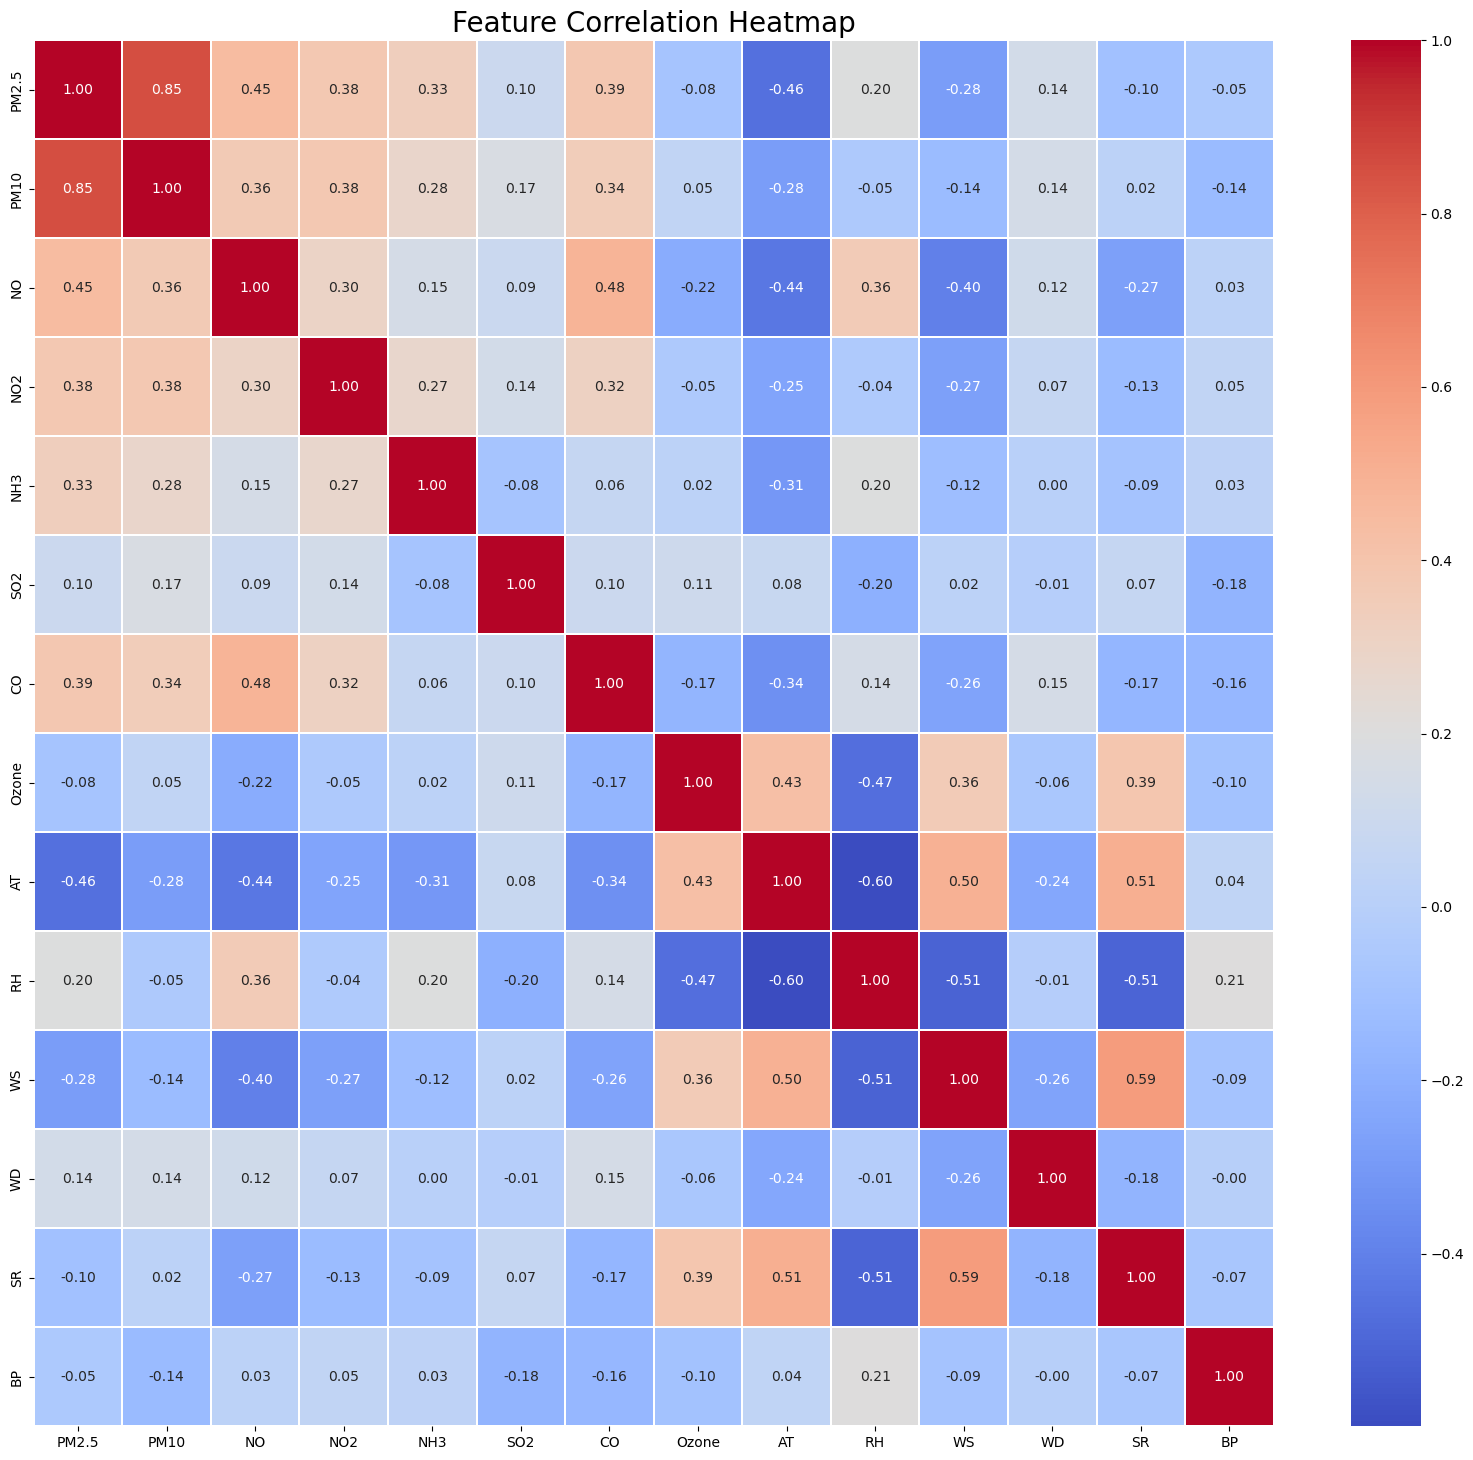

In [274]:
plt.figure(figsize=(20, 18))
sns.heatmap(df.iloc[:, 1:].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Feature Correlation Heatmap', fontsize=20)
plt.show()

In [275]:
# PM2.5 trend
fig = px.line(df, x='Timestamp', y='PM2.5', title='PM2.5 trend')

fig.update_xaxes(
    rangeslider_visible = True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label='1y', step='year', stepmode='backward'),
            dict(count=2, label='3y', step='year', stepmode='backward'),
            dict(count=3, label='5y', step='year', stepmode='backward'),
            dict(step='all')
        ])
    )
)

fig.update_layout(
    width=1200,   # try 1000–1600 depending on your screen
    height=600
)
fig.show()

# 2. Preprocessing

## 2.1 Outlier Visualization

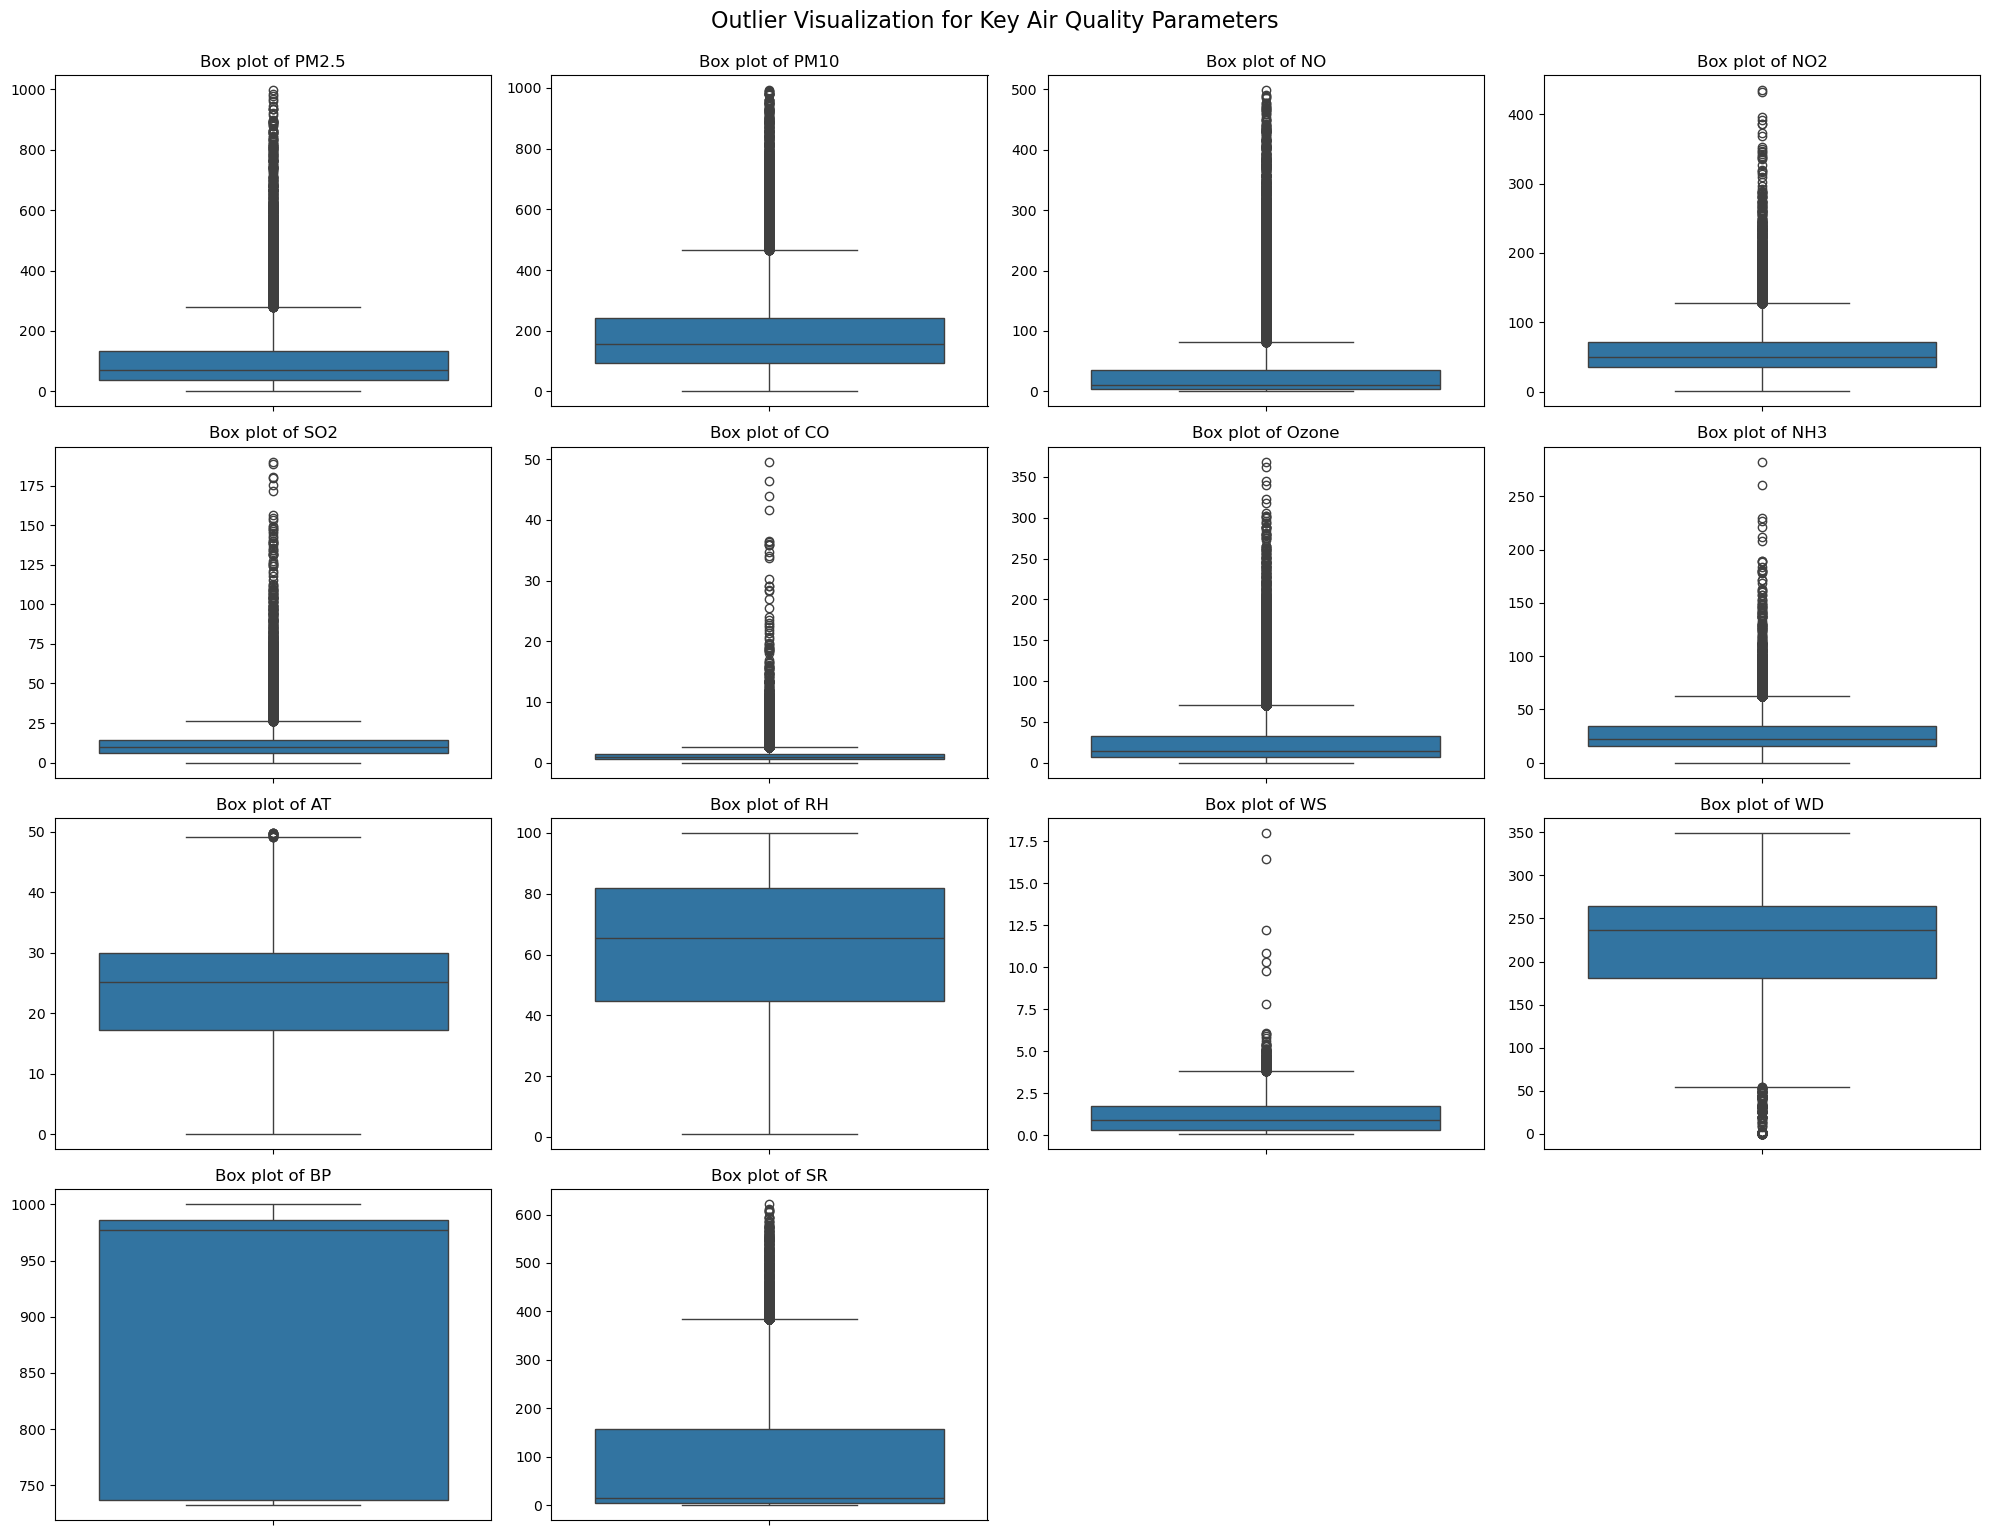

In [276]:
# Select the main air quality parameters for outlier visualization
outlier_columns = ['PM2.5', 'PM10', 'NO', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'AT', 'RH', 'WS', 'WD', 'BP', 'SR']

# Create box plots for each selected column to visualize outliers
plt.figure(figsize=(20, 15))
for i, col in enumerate(outlier_columns):
    plt.subplot(4, 4, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('') # Remove y-axis label to avoid clutter
plt.tight_layout()
plt.suptitle('Outlier Visualization for Key Air Quality Parameters', y=1.02, fontsize=16)
plt.show()

## 2.2 Train Test Split

In [277]:
# sort by time
df = df.sort_values("Timestamp").reset_index(drop=True)

# time-based split (80% train, 20% test)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()


In [278]:
train_df.shape

(70137, 15)

In [279]:
test_df.shape

(17535, 15)

In [280]:
train_df.isna().sum()

Timestamp        0
PM2.5         8721
PM10          8797
NO           10862
NO2           9919
NH3          10500
SO2          11188
CO           10930
Ozone        10187
AT            8597
RH            7706
WS            7551
WD            8367
SR            7456
BP            7760
dtype: int64

In [281]:
test_df.isna().sum()

Timestamp       0
PM2.5        1978
PM10         1641
NO           1215
NO2          1198
NH3          1238
SO2          1938
CO           1598
Ozone        1664
AT           1661
RH           2458
WS           1659
WD           1666
SR           2195
BP           1875
dtype: int64

## 2.3 Missing Value Handling

In [282]:
df.isna().sum()

Timestamp        0
PM2.5        10699
PM10         10438
NO           12077
NO2          11117
NH3          11738
SO2          13126
CO           12528
Ozone        11851
AT           10258
RH           10164
WS            9210
WD           10033
SR            9651
BP            9635
dtype: int64

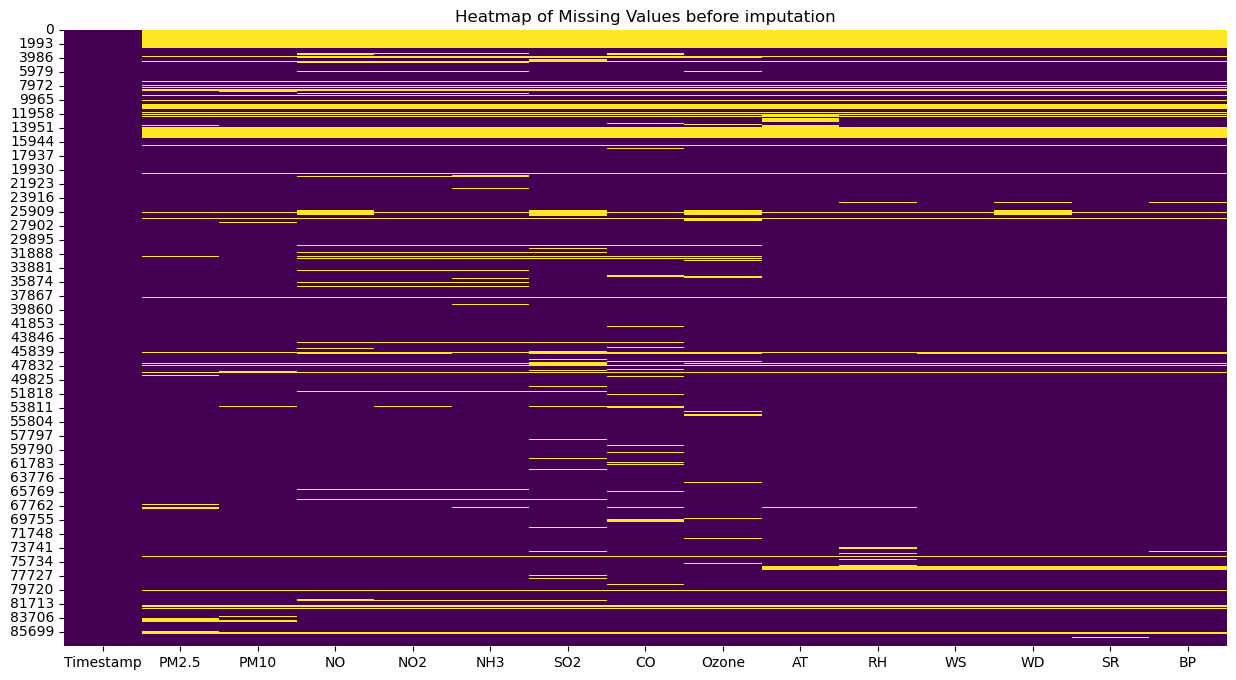

In [283]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values before imputation')
plt.show()

### 2.3.1 Missing value Imputation

In [284]:
#doing separately due to data leakage
train_df = train_df.interpolate(method='linear', limit=3) #if do linear interpolation for both train test then data leakage

# for test: only forward-fill (no future access)
test_df = test_df.ffill(limit=3)

In [285]:
# train_df["PM25_missing"] = train_df["PM2.5"].isna().astype(int)
# test_df["PM25_missing"]  = test_df["PM2.5"].isna().astype(int)

# ## not so much improvement with this

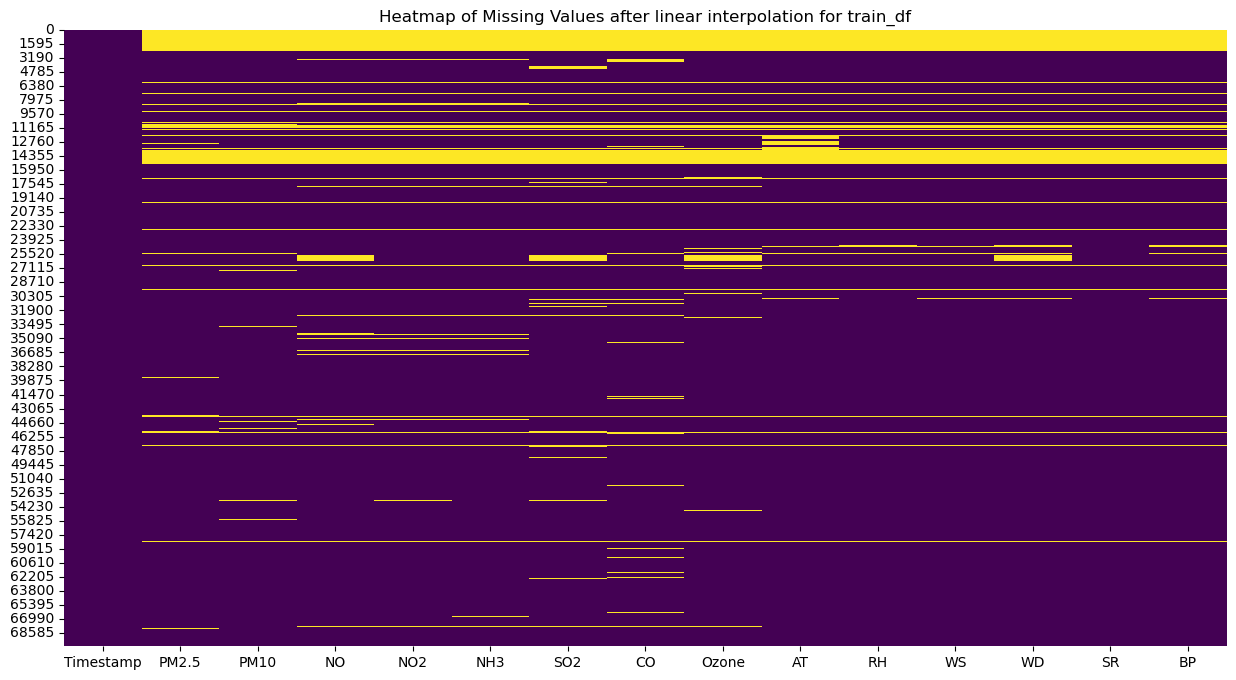

In [286]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values after linear interpolation for train_df')
plt.show()

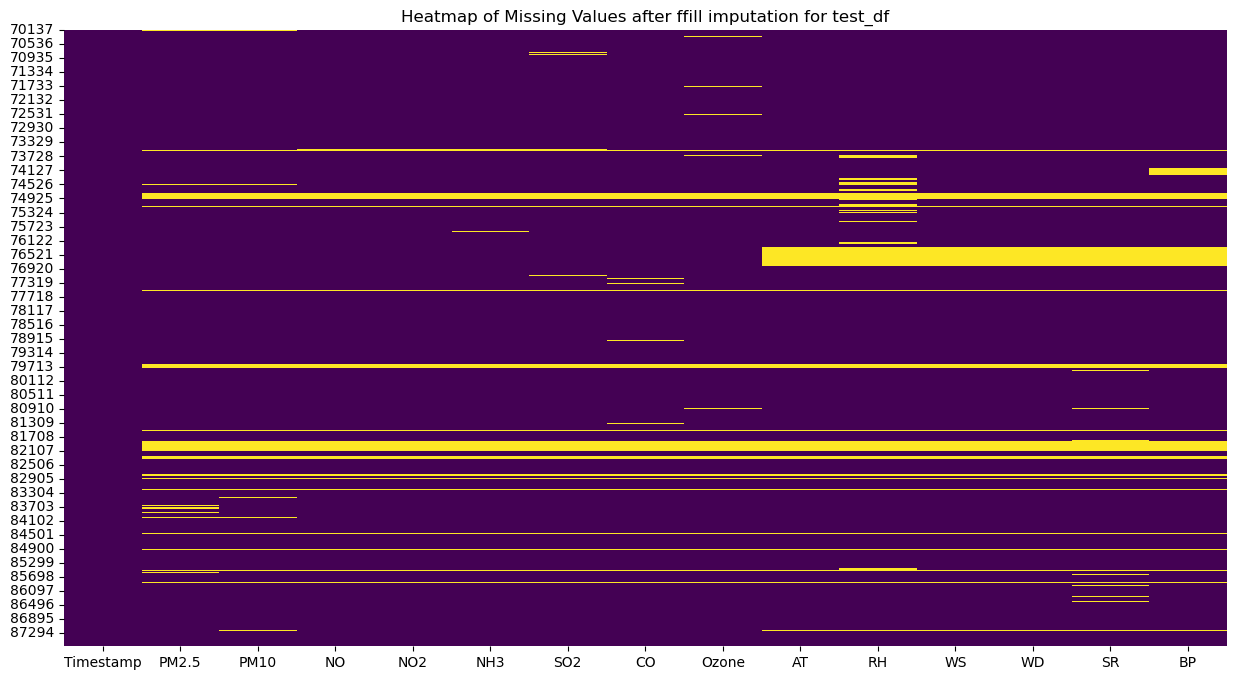

In [287]:
plt.figure(figsize=(15, 8))
sns.heatmap(test_df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values after ffill imputation for test_df')
plt.show()

In [288]:
train_df.isna().sum()

Timestamp       0
PM2.5        7526
PM10         7640
NO           9353
NO2          8586
NH3          9077
SO2          9516
CO           9103
Ozone        8741
AT           7994
RH           7113
WS           6965
WD           7785
SR           6862
BP           7154
dtype: int64

In [289]:
test_df.isna().sum()

Timestamp       0
PM2.5        1192
PM10         1046
NO            974
NO2           970
NH3          1011
SO2          1117
CO           1102
Ozone        1127
AT           1484
RH           2052
WS           1476
WD           1480
SR           1706
BP           1695
dtype: int64

# 3. LightGBM model

## 3.1 Feature Engineering for LightGBM model

In [290]:
#time features added for train
train_df['hour'] = train_df['Timestamp'].dt.hour
train_df['dayofweek'] = train_df['Timestamp'].dt.dayofweek
train_df['month'] = train_df['Timestamp'].dt.month
train_df['dayofyear'] = train_df['Timestamp'].dt.dayofyear

#time features added for test
test_df['hour'] = test_df['Timestamp'].dt.hour
test_df['dayofweek'] = test_df['Timestamp'].dt.dayofweek
test_df['month'] = test_df['Timestamp'].dt.month
test_df['dayofyear'] = test_df['Timestamp'].dt.dayofyear



In [291]:
for lag in [1, 2, 3, 6, 12, 24]:
    train_df[f"PM25_lag_{lag}"] = train_df["PM2.5"].shift(lag)
    test_df[f"PM25_lag_{lag}"]  = test_df["PM2.5"].shift(lag)


In [292]:
target = "PM2.5"

feature_cols = [
    col for col in train_df.columns
    if col not in ["PM2.5", "Timestamp", "WD"]
]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test  = test_df[feature_cols]
y_test  = test_df[target]


In [293]:
train_df.head()

,Timestamp,PM2.5,PM10,NO,NO2,NH3,SO2,CO,Ozone,AT,...,hour,dayofweek,month,dayofyear,PM25_lag_1,PM25_lag_2,PM25_lag_3,PM25_lag_6,PM25_lag_12,PM25_lag_24
0,2015-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,3,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,3,1,1,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,3,1,1,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,3,1,1,NaN,NaN,NaN,NaN,NaN,NaN


In [294]:
feature_cols

['PM10',
 'NO',
 'NO2',
 'NH3',
 'SO2',
 'CO',
 'Ozone',
 'AT',
 'RH',
 'WS',
 'SR',
 'BP',
 'hour',
 'dayofweek',
 'month',
 'dayofyear',
 'PM25_lag_1',
 'PM25_lag_2',
 'PM25_lag_3',
 'PM25_lag_6',
 'PM25_lag_12',
 'PM25_lag_24']

In [295]:
X_train.shape

(70137, 22)

In [296]:
y_train.shape

(70137,)

In [297]:
X_test.shape

(17535, 22)

In [298]:
y_test.shape

(17535,)

In [299]:
#LightGBM TRAIN ONLY
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

   

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4876
[LightGBM] [Info] Number of data points in the train set: 70137, number of used features: 22
[LightGBM] [Info] Start training from score 90.100807


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
              random_state=42, subsample=0.8)

In [300]:
preds = model.predict(X_test)

# 4. Evaluation

In [301]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Find indices where y_test actually has data
valid_idx = ~np.isnan(y_test)

# Calculate metrics only on these valid points
mae = mean_absolute_error(y_test[valid_idx], preds[valid_idx])
mse = mean_squared_error(y_test[valid_idx], preds[valid_idx])
rmse = np.sqrt(mse)
r2 = r2_score(y_test[valid_idx], preds[valid_idx])

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

#lightGBM with lag features ----> huge score 

MAE  : 12.3734
MSE  : 364.6276
RMSE : 19.0952
R²   : 0.9577


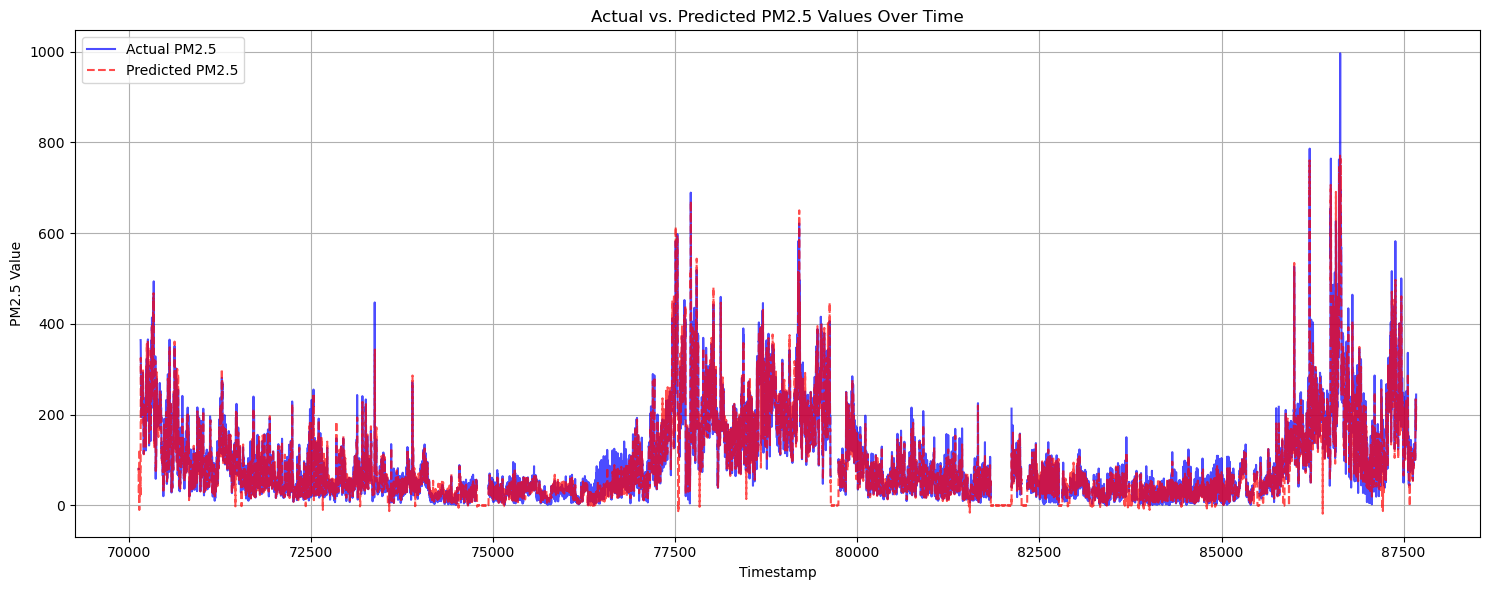

In [302]:
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test, label='Actual PM2.5', color='blue', alpha=0.7)
plt.plot(y_test.index, preds, label='Predicted PM2.5', color='red', linestyle='--', alpha=0.7)
plt.title('Actual vs. Predicted PM2.5 Values Over Time')
plt.xlabel('Timestamp')
plt.ylabel('PM2.5 Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [303]:
import plotly.graph_objects as go
import pandas as pd

# Ensure Timestamp is datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Rebuild y_test dataframe with correct timestamps
y_test_df = pd.DataFrame({
    'Timestamp': df.loc[y_test.index, 'Timestamp'].values
        if y_test.index.isin(df.index).all()
        else df['Timestamp'].iloc[-len(y_test):].values,
    'Actual': y_test.values,
    'Predicted': preds
})

# Plot
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=y_test_df['Timestamp'],
        y=y_test_df['Actual'],
        mode='lines',
        name='Actual PM2.5',
        line=dict(color='blue'),
        opacity=0.7
    )
)

fig.add_trace(
    go.Scatter(
        x=y_test_df['Timestamp'],
        y=y_test_df['Predicted'],
        mode='lines',
        name='Predicted PM2.5',
        line=dict(color='red', dash='dash'),
        opacity=0.7
    )
)

fig.update_layout(
    title='Actual vs Predicted PM2.5 Over Time',
    xaxis_title='Timestamp',
    yaxis_title='PM2.5 Value',
    width=1200,
    height=600,
    template='plotly_white'
)

fig.update_xaxes(
    type='date',
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=[
            dict(count=1, label='1y', step='year', stepmode='backward'),
            dict(step='all')
        ]
    )
)

fig.show()


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

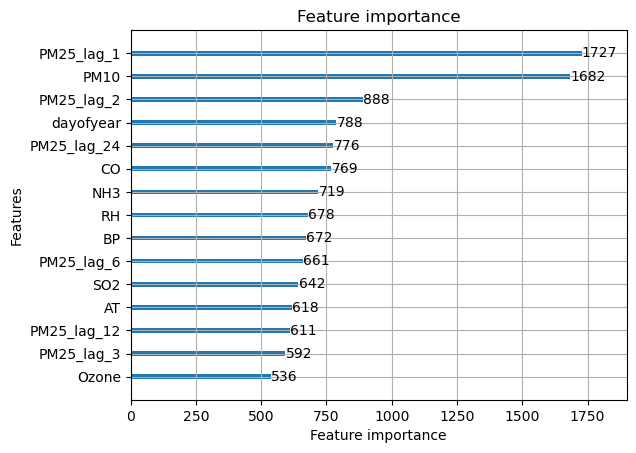

In [304]:
lgb.plot_importance(model, max_num_features=15)